In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier

In [2]:
#Load Data
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

print("Dataset loaded")

Dataset loaded


In [3]:
print(X.head())
print(X.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [5]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
#cek missing value
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


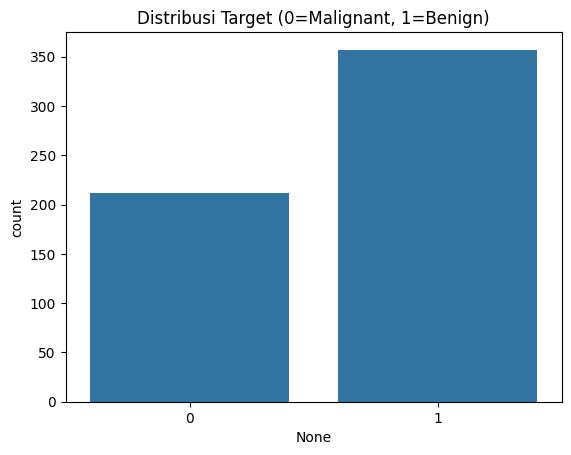

In [8]:
#cek distribusi target
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Distribusi Target (0=Malignant, 1=Benign)")
plt.show()

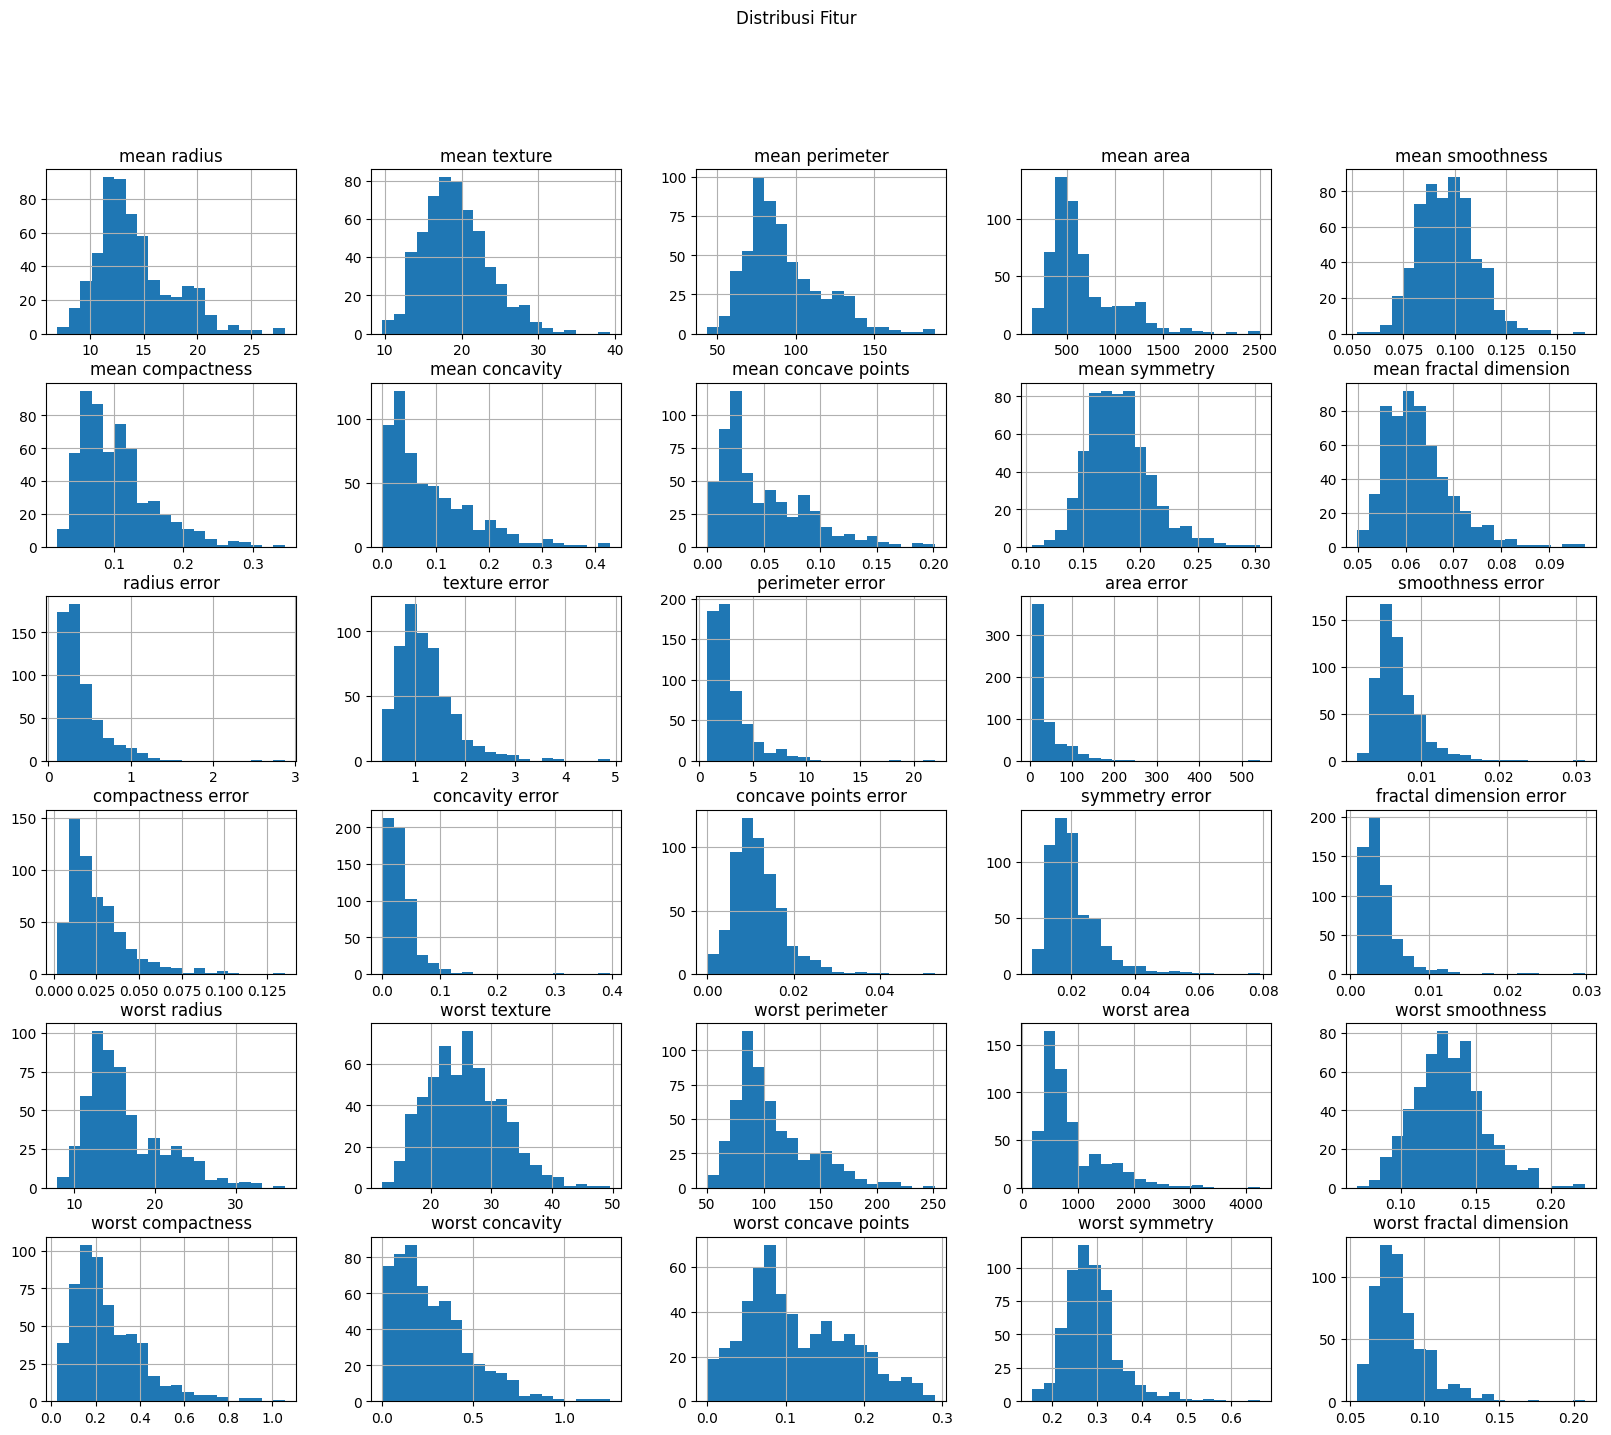

In [10]:
#Distribusi Fitur
X.hist(figsize=(20,16), bins=20)
plt.suptitle("Distribusi Fitur")
plt.show()

In [11]:
#korelasi fitur terhadap target
corr_with_target = X.copy()
corr_with_target['target'] = y

corr_target = corr_with_target.corr()['target'].sort_values(ascending=False)

print(corr_target)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

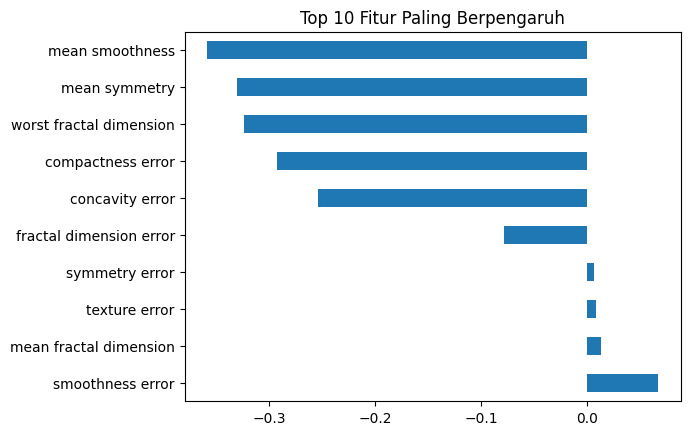

In [12]:
top_features = corr_target[1:11]  # top 10 fitur (exclude target)

top_features.plot(kind='barh')
plt.title("Top 10 Fitur Paling Berpengaruh")
plt.show()

##Preprocessing

In [13]:
# Convert kolom object ke numeric
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')

In [14]:
print(X.dtypes)
print(X.isnull().sum())

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [15]:
corr_with_target = X.copy()
corr_with_target['target'] = y

corr_target = corr_with_target.corr()['target'].abs().sort_values(ascending=False)

# ambil top 15 fitur terbaik
selected_features = corr_target[1:16].index

X = X[selected_features]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['worst concave points', 'worst perimeter', 'mean concave points',
       'worst radius', 'mean perimeter', 'worst area', 'mean radius',
       'mean area', 'mean concavity', 'worst concavity', 'mean compactness',
       'worst compactness', 'radius error', 'perimeter error', 'area error'],
      dtype='object')


##Modelling

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
# The data has already been split and scaled in previous steps.
# This cell only needs to print the shapes for verification.

print(f"\n✓ Data telah di-scale dan di-split")
print(f"  - Training: {X_train.shape[0]} sampel")
print(f"  - Testing: {X_test.shape[0]} sampel")


✓ Data telah di-scale dan di-split
  - Training: 455 sampel
  - Testing: 114 sampel


##Evaluation

HistGradientBoostingClassifier Accuracy: 0.956140350877193

HistGradientBoostingClassifier Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



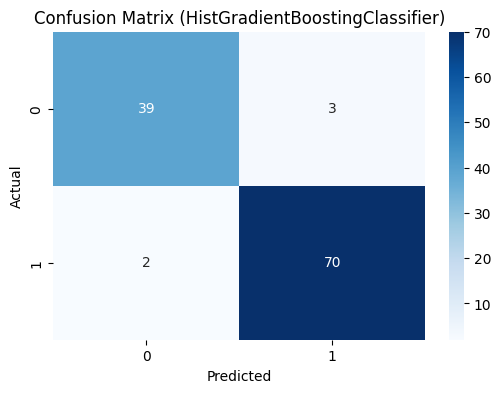

In [57]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)

acc_hgb = accuracy_score(y_test, y_pred_hgb)
print("HistGradientBoostingClassifier Accuracy:", acc_hgb)

print("\nHistGradientBoostingClassifier Classification Report:\n")
print(classification_report(y_test, y_pred_hgb))

cm_hgb = confusion_matrix(y_test, y_pred_hgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (HistGradientBoostingClassifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()